# Streaming training with LSDB datasets and Hyrax

## Open a TESS lightcurve catalog
We'll open the TESS lightcurve catalog from LSDB and filter down the observations
to non-NaN values and ensure that the lightcurves have at least 100 observations.

The steps would be similar for working with other lightcurve catalogs as well - i.e. DP2 HATS catalog.

In [1]:
import lsdb

tess = lsdb.open_catalog("https://data.lsdb.io/hats/tess/tess_lightcurve")

## Use LSDB to operate on the TESS catalog

As noted before, LSDB creates a deferred promise of a catalog as you interact with it.
This allows you to build up complex queries and transformations on the catalog without immediately fetching all the data.

In this case, we'll build up a query to filter the TESS catalog for lightcurves with at least 100 observations after removing any NaN values.

In [ ]:
from nested_pandas.utils import count_nested

def drop_nans(df):
    # 1. Drop the rows where lightcurve.sap_flux is NaN
    # 2. Also remove all the resulting objects with no lightcurve points remaining
    df["lightcurve.sap_flux"] = df["lightcurve.sap_flux"].astype(float)
    return df.dropna(subset=["lightcurve.sap_flux"]).dropna(subset=["lightcurve"])

tess_filtered_nans = tess.map_partitions(drop_nans)

def count_points(pts):
    # Asked to count `lightcurve`, this will add a column called `n_lightcurve`
    return count_nested(pts, "lightcurve")

min_observations = 100
tess_filtered_nans = tess_filtered_nans.map_partitions(count_points).query(
    f"n_lightcurve >= {min_observations}"
)

## Using Hyrax with LSDB

In the next few cells, we'll demonstrate how to use Hyrax to work with the deferred promise from LSDB to train and examine the output of a model.

First we instantiate Hyrax and register the deferred promise from LSDB.

In [ ]:
from hyrax import Hyrax
from hyrax.datasets import LSDBStreamDataset

h = Hyrax()

LSDBStreamDataset.register_catalog("tess_catalog", tess_filtered_nans)

## Specify configuration parameters for training

In [ ]:
data_request = {
    "train_stream": {
        "data": {
            "dataset_class": "LightCurveLSDBStreamDataset",
            "data_location": "lsdb://tess_catalog",
            "primary_id_field": "ticid",
            "fields": [
                "lightcurve_time",
                "lightcurve_sap_flux",
                "lightcurve_sap_flux_err",
            ],
        }
    }
}
h.set_config("data_request", data_request)

h.set_config("model.name", "HyraxTs2Vec")

# TESS is single-band, so there is no band column: drop the one-hot block.
# This leaves 3 channels — flux, flux error, log time gap.
h.set_config("data_set.LightCurveLSDBStreamDataset.band_field", False)
h.set_config("data_set.LightCurveLSDBStreamDataset.time_field", "lightcurve_time")
h.set_config("data_set.LightCurveLSDBStreamDataset.flux_field", "lightcurve_sap_flux")
h.set_config("data_set.LightCurveLSDBStreamDataset.flux_err_field", "lightcurve_sap_flux_err")
h.set_config("data_set.LightCurveLSDBStreamDataset.max_sequence_length", 256)

# Set stream_type to "infinite" for continuous streaming - note: we only use a few batches for this demo
h.set_config("data_set.LSDBStreamDataset.stream_type", "infinite")
h.set_config("data_set.LSDBStreamDataset.partitions_per_chunk", 2)

# Set the training batch size
h.set_config("data_loader.batch_size", 64)

## Iterate over the training stream

In [ ]:
import tqdm

batch_counter = 0
MAX_BATCHES = 100

with h.train_stream() as session:
    for batch, metrics in tqdm.tqdm(session):
        batch_counter += 1

        if batch_counter >= MAX_BATCHES:
            break

[2026-09-18 16:44:15,990 hyrax.datasets.lsdb_stream_dataset:INFO] No active dask.distributed Client was found, so lsdb will compute each chunk synchronously and every fetch will block the consumer. Create a client before starting the run - Client(processes=False) keeps results in-process and avoids serializing every chunk back from a worker.
[2026-09-18 16:44:15,990 hyrax.datasets.lsdb_stream_dataset:WARNING] config['data_set']['LSDBStreamDataset']['shuffle'] is ignored when stream_type = 'infinite'; lsdb's InfiniteStream always shuffles.
[2026-09-18 16:44:50,966 hyrax.models.model_registry:WARNING] Both model and config define an optimizer. Hyrax will use self.optimizer defined in the model.
[2026-09-18 16:44:50,966 hyrax.models.model_registry:INFO] Using self.optimizer defined in model: torch.optim.adamw.AdamW
[2026-09-18 16:44:50,967 hyrax.models.model_registry:WARNING] Both model and config define a criterion. Hyrax will use self.criterion defined in the model.
[2026-09-18 16:44:50

## Configure and run inference with Hyrax

In [ ]:
from hyrax.config_utils import find_most_recent_results_dir

data_request = {
    "infer_stream": {
        "data": {
            "dataset_class": "LightCurveLSDBStreamDataset",
            "data_location": "lsdb://tess_catalog",
            "primary_id_field": "ticid",
            "fields": [
                "lightcurve_time",
                "lightcurve_sap_flux",
                "lightcurve_sap_flux_err",
            ],
        }
    }
}
h.set_config("data_request", data_request)

# Stream type "catalog" makes exactly one pass through the data.
h.set_config("data_set.LSDBStreamDataset.stream_type", "catalog")
h.set_config("data_set.LSDBStreamDataset.shuffle", False)

h.set_config("data_loader.batch_size", 256)

# Specify the location of the trained model weights
train_dir = find_most_recent_results_dir(h.config, "train_stream")
h.set_config(
    "infer_stream.model_weights_file",
    str(train_dir / h.config["train_stream"]["weights_filename"]),
)

batch_counter = 0
with h.infer_stream() as session:
    for batch, metrics in tqdm.tqdm(session):
        batch_counter += 1

        if batch_counter >= MAX_BATCHES:
            break

[2026-09-18 16:46:15,739 hyrax.datasets.lsdb_stream_dataset:INFO] No active dask.distributed Client was found, so lsdb will compute each chunk synchronously and every fetch will block the consumer. Create a client before starting the run - Client(processes=False) keeps results in-process and avoids serializing every chunk back from a worker.
[2026-09-18 16:46:35,415 hyrax.models.model_registry:WARNING] Both model and config define an optimizer. Hyrax will use self.optimizer defined in the model.
[2026-09-18 16:46:35,416 hyrax.models.model_registry:INFO] Using self.optimizer defined in model: torch.optim.adamw.AdamW
[2026-09-18 16:46:35,416 hyrax.models.model_registry:WARNING] Both model and config define a criterion. Hyrax will use self.criterion defined in the model.
[2026-09-18 16:46:35,416 hyrax.models.model_registry:INFO] Using self.criterion defined in model: hyrax.models.hyrax_ts2vec.HierarchicalContrastiveLoss
[2026-09-18 16:46:35,417 hyrax.models.model_registry:INFO] Setting mo

## Reduce the latent space dimensionality

By default, the `ts2vec` model produces a 320D latent representation for each object.
To visualize this we process each latent space vector with UMAP, and then plot the resulting 2D embeddings.

In [8]:
infer_dir = find_most_recent_results_dir(h.config, "infer_stream")
umap_results = h.reduce_dimensions(input_dir=infer_dir)

[2026-09-18 16:53:24,186 hyrax.verbs.reduce_dimensions:INFO] Saving reduction results using umap to /home/drew/code/hyrax-wt-ts2vec/docs/pre_executed/results/20260918-165324-umap-LCck
[2026-09-18 16:53:24,187 hyrax.verbs.reduce_dimensions:INFO] Using most recent inference results dataset for dimensionality reduction.
[2026-09-18 16:53:25,036 hyrax.verbs.reduce_dimensions:INFO] No model_path specified. A new model will be fitted.
[2026-09-18 16:53:25,046 hyrax.verbs.reduction_algorithms.umap:INFO] Fitting the UMAP
[2026-09-18 16:53:31,023 hyrax.verbs.reduce_dimensions:INFO] Saving fitted umap reducer to result directory


Creating lower dimensional representation using UMAP::   0%|          | 0/25 [00:00<?, ?it/s]

[2026-09-18 16:54:12,081 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 25 batches
[2026-09-18 16:54:12,102 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-09-18 16:54:12,102 hyrax.verbs.reduce_dimensions:INFO] Finished transforming all data with umap


## Plot the 2D embeddings

Note that the data returned from UMAP is a `lance` dataset, so we'll convert it to numpy arrays before plotting.

In [9]:
import numpy as np

# Stack all UMAP embeddings into a single array.
umap_embeddings = np.array([umap_results[i] for i in range(len(umap_results))])
print(f"Shape: {umap_embeddings.shape}  (samples × components)")

Shape: (25600, 2)  (samples × components)


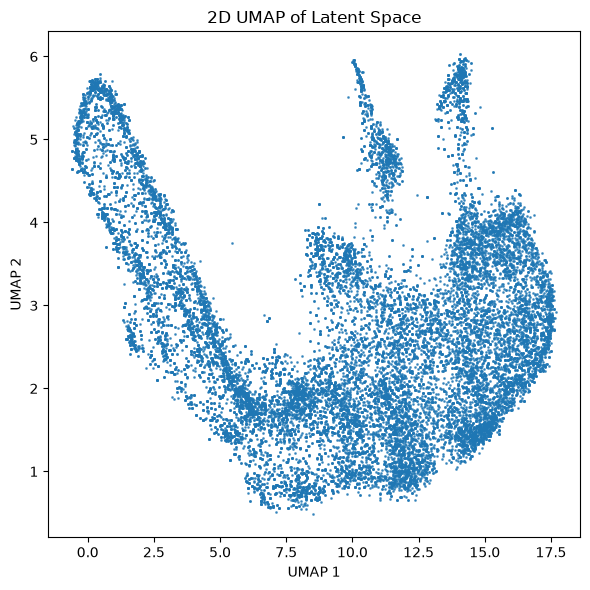

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], s=1, alpha=0.7)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("2D UMAP of Latent Space")
plt.tight_layout()
plt.show()